# Smoothing Test Results

In this notebook, we present results from the smoothing test. We present the result for one specific CD-SSM. This notebooks consists of 4 parts:

- Part 1: Plot of the CD-SSM.
- Part 2: Plot of the true filtering and smoothing marginal distributions.
- Part 3: Evaluate performance of CDSSM MCMC based particle smoothing methods (The smoothing test)
- Part 4: (Optional) View traceplots of the MCMC outputs for the materially different distributions.
- Part 5: (Optional): Run a smoothing MCMC algorithm for a single Feynman-Kac model, review the results.

## To do

### Profiling your code 

- Correct the instances in `sdes.py` where you are looping over the number of particles N: to create N matrices: this is inefficient!
- Review what you did with `_diag_cov`, and ensure that the right diffusion process is being called in the background. Check the way that 
this changes how the CD-SSM is defined.
- Run the filtering test on everything, and make sure all the implementations are correct.

### Consider non-linear smoothing example

- Look back at the formulation of the FHN model in the notes that Alex sent you on the reparameterisation. Start thinking about how you are going to implement this example, and write some things down.

### Showing your results 

- Try to come up with some results that show the out performance of the backward step on a simple example, such as the 1-D OU process, or some other 1-D process. 

In [1]:
import arviz as az
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from particles.utils import multiplexer

from particles_cdssm.mcmc import mcmc_worker
import particles_cdssm.plot as splt
from particles_cdssm.continuous_discrete_ssms import NormalCDSSM, MvNormalCDSSM
import particles_cdssm.feynman_kac as sfk

Select the CD-SSM that you would like to present results for, along with the run-id below:

In [2]:
run_id = '20'
cdssm_str = 'mv_ou'

part_1 = pd.read_json(f'./results/smoothing_mcmc_test_run_{run_id}_{cdssm_str}_part_1.json')

alg_names = ['pimh', 'icsmc', 'icsmc_bs']
part_2 = {alg_name: az.from_netcdf(f'./results/smoothing_mcmc_test_run_{run_id}_{cdssm_str}_part_2_{alg_name}.nc') for alg_name in alg_names}    

with open(f'./results/smoothing_test_run_{run_id}_{cdssm_str}_meta.pkl', 'rb') as f:
    part_3 = dill.load(f)

In [3]:
true_vals_df = part_1.copy()
idatas = part_2
metadata = part_3

idata = idatas[alg_names[0]]

# # Extract the metadata
cdssm = metadata['cdssm']
lgssm = metadata['lgssm']
x = metadata['x']
y = metadata['y']
T = idata.observed_data.dims['time']
num = metadata['num']

obs_times = metadata['stored_obs_times']
if cdssm.isobservedat0:
    cts_obs_times = np.array([cdssm.S(t) for t in obs_times], dtype=np.float64)
else:
    cts_obs_times = np.array([cdssm.S(t+1) for t in obs_times], dtype=np.float64)
posterior_coords = list(idatas['pimh'].posterior.coords)

ext = '' if cdssm.islgssm else '_pf'

print(f'Model: {cdssm_str}, T: {T}, num: {num}')

Model: mv_ou, T: 100, num: 20


/var/folders/0k/hbxf9b9s63n8x4vbrs41s02w0000gn/T/ipykernel_77217/3831576333.py:12: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  T = idata.observed_data.dims['time']


# Part 1: Plot of the CD-SSM

We plot below the simulation of the CD-SSM of interest. We choose a model such that ratio of observation noise/signal noise is high. The smoothing distribution changes materially as the total number of observations increases. 

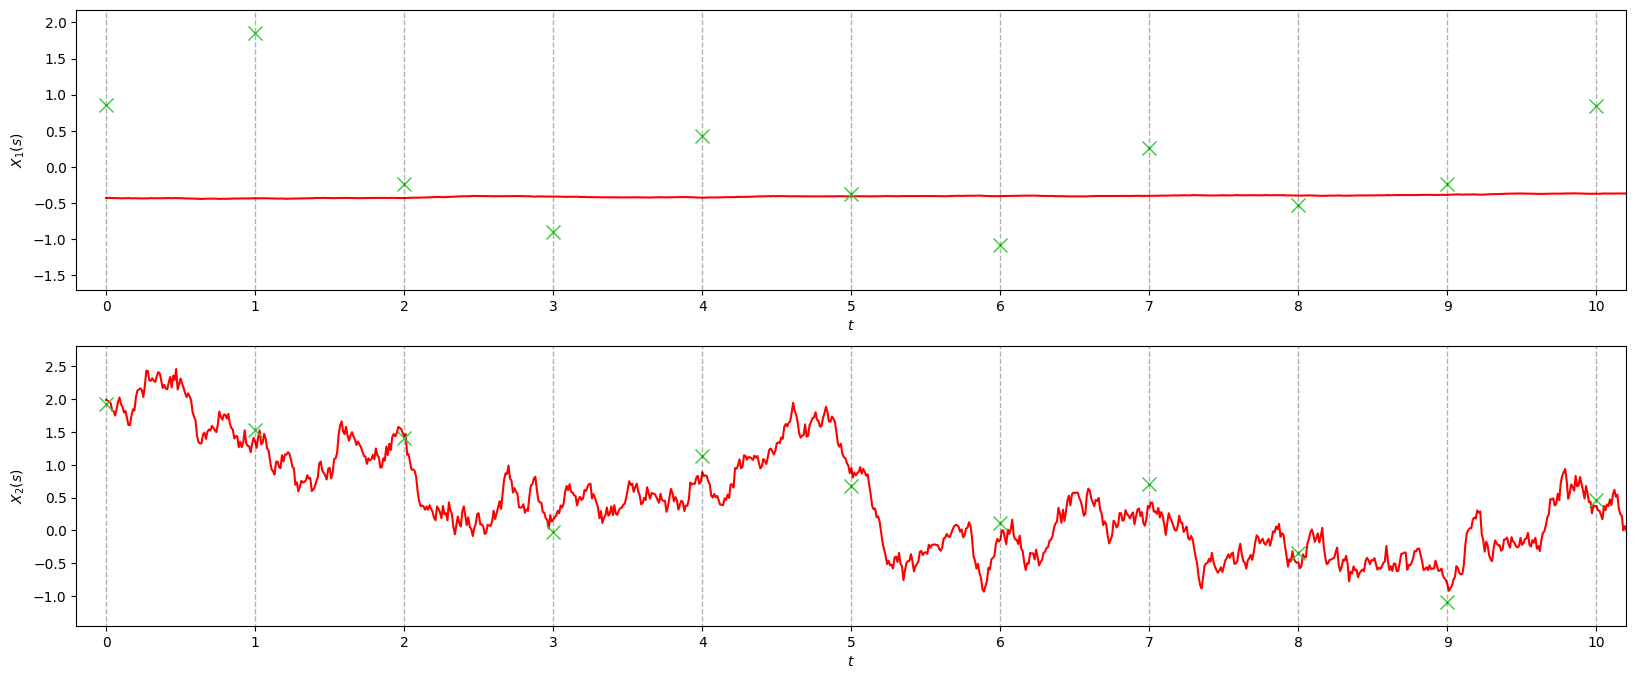

In [4]:
plot_T = 10

x_plt = x[:plot_T + 2]
y_plt = y[:plot_T + 2]

#quantiles = metadata['quantiles']

if isinstance(cdssm, NormalCDSSM): 
    fig, axes = splt.cdssm_simulation_plot(cdssm, x_plt, y_plt)
elif isinstance(cdssm, MvNormalCDSSM):
    fig, axes = splt.mv_cdssm_simulation_plot(cdssm, x_plt, y_plt)
else:
    pass

if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

for ax in axes:
    ax.set_xlim((-0.2, plot_T + 0.2))
plt.show()

# Can add custom changes to the fig/axes below:

# Part 2: Plot of the true filtering and smoothing marginal distributions

## Plot of the true Smoothing Distributions

We plot for each of the stored observations times, the filtering distribution vs the smoothing distribution. From the plot, we can distinguish which marginals may be materially different: 

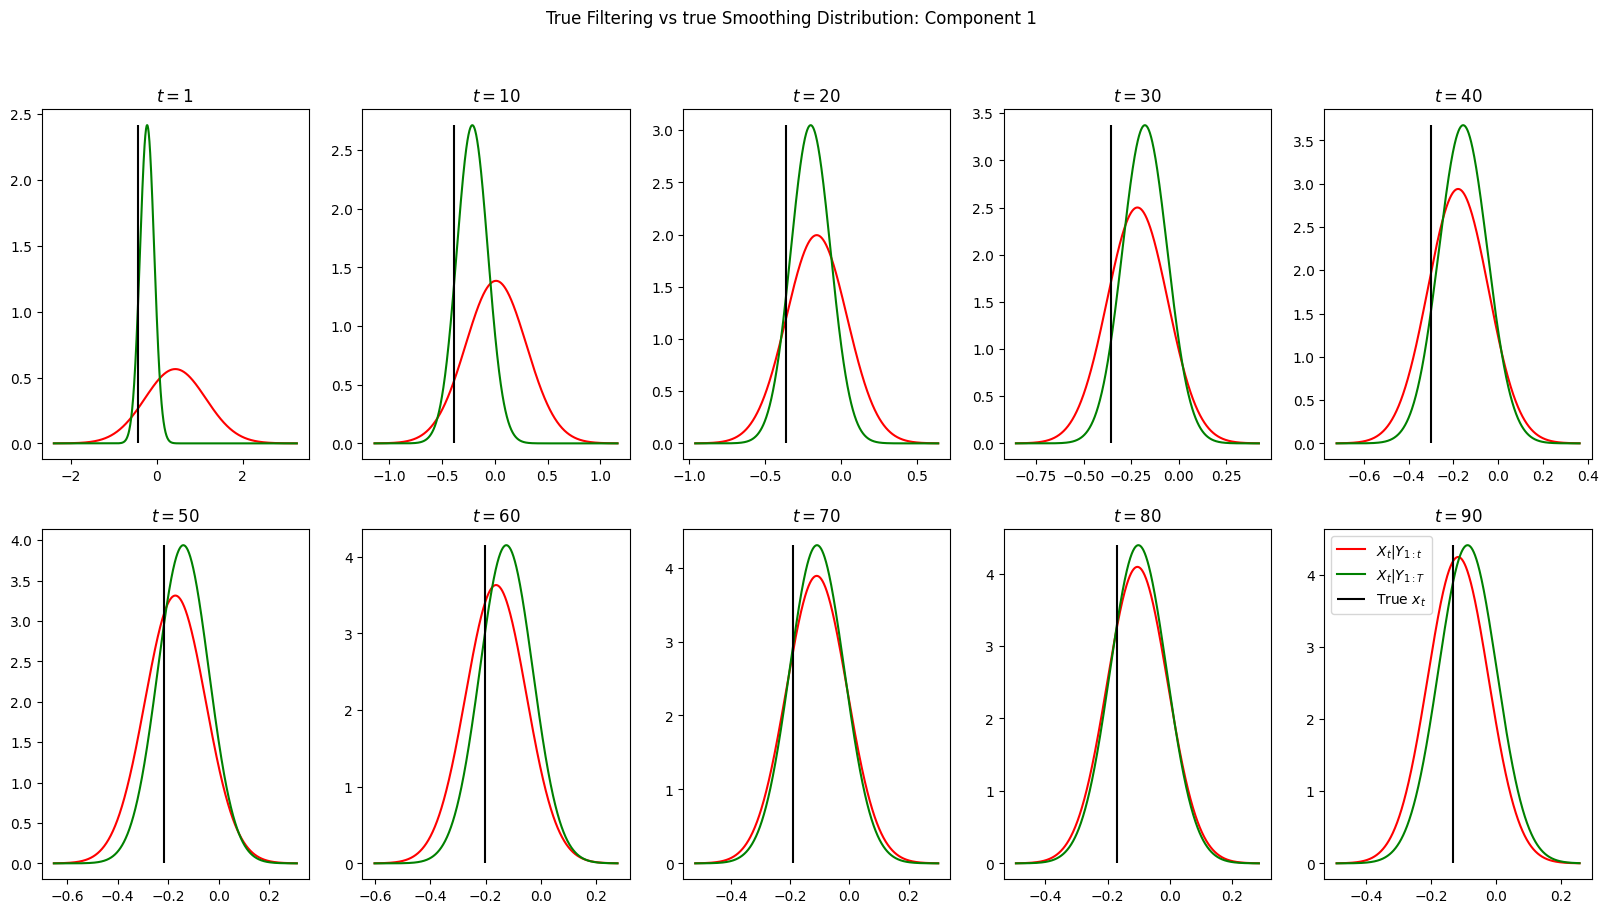

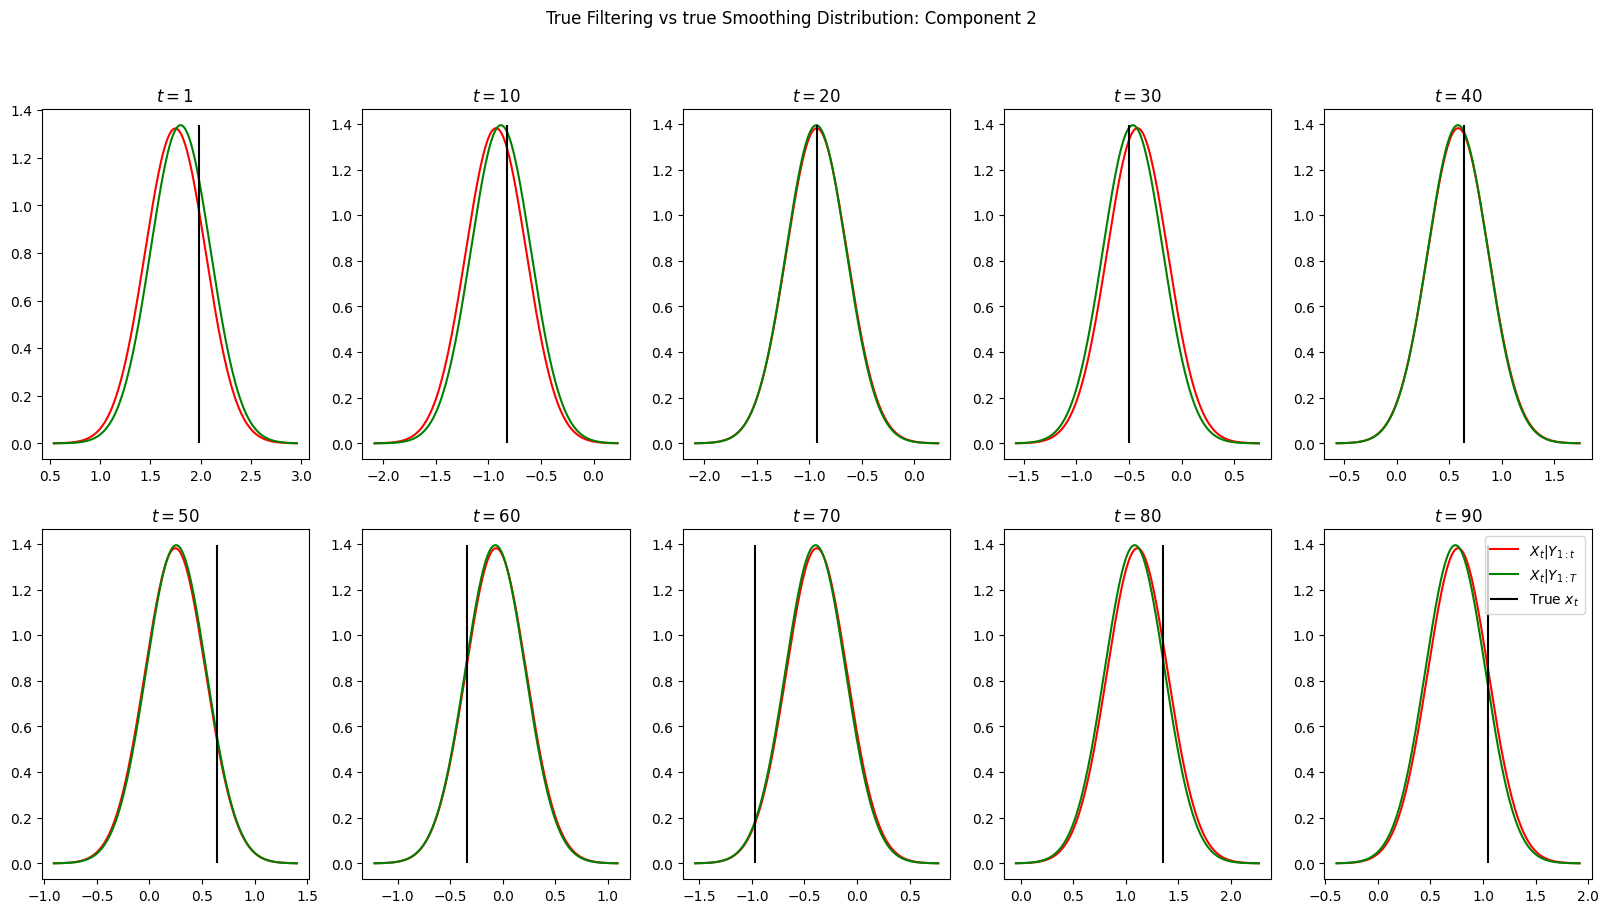

In [5]:
for j in range(1, cdssm.dimX +1):
    fig, axes = plt.subplots(2, 5, figsize=(20, 10))
    axes = axes.ravel()

    for k, ax in enumerate(axes):
        t = obs_times[k]
        x_t_true = x[t][x[t].dtype.names[-1]].ravel()

        x_lim_lower = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'] - 4. * true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']
        x_lim_upper = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'] + 4. * true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']

        x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

        filt_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'], scale=true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}'])
        smth_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_smth_mean_{j}{ext}'], scale=true_vals_df.loc[t, f'x_t_smth_std_{j}{ext}'])
        y_max = np.max([np.max(filt_pdf_linsp), np.max(smth_pdf_linsp)])

        ax.plot(x_linsp, filt_pdf_linsp, '-', c='red', label=r'$X_t|Y_{1:t}$')
        ax.plot(x_linsp, smth_pdf_linsp, '-', c='green', label=r'$X_t|Y_{1:T}$')

        ax.vlines(x_t_true[j-1], ymin=0.0, ymax=y_max, colors='black', label=r'True $x_t$')
        ax.set_title(f'$t={t+1}$')
    plt.legend()
    plt.suptitle(f'True Filtering vs true Smoothing Distribution: Component {j}')
    plt.show()

# Part 3: Evaluate performance of CD-SSM particle smoothing methods (The smoothing test)


We test for each possible Feynman-Kac model that we can build with the CD-SSM, whether the `FFBS_MCMC` method targets the smoothing distribution. We do this by first selecting out of the marginal distributions plotted, above, for which of them it holds that the smoothing distribution is materially different from the filtering distribution:

In [6]:
signif_dist_tol = 1.5 # The filtering mean must be at least `signif_dist_tol` std devs away from the smoothing mean to be considered significant

for d in range(1, cdssm.dimX + 1):
    true_vals_df[f'x_t_high_diff_{d}'] = np.abs(true_vals_df[f'x_t_smth_mean_{d}'] - true_vals_df[f'x_t_filt_mean_{d}']) > signif_dist_tol * true_vals_df[f'x_t_smth_std_{d}']
    
n_signif_dists = np.sum([np.sum(true_vals_df[f'x_t_high_diff_{d}']) for d in range(1, cdssm.dimX + 1)])

if n_signif_dists > 0:
    print(f'Materially different distributions found: {n_signif_dists}')
else:
    raise ValueError('No materially different distributions found. Try a different model parameterisation.')

Materially different distributions found: 2


For the materially different marginals we then assess for each Feynman-Kac model, whether the estimator of the smoothing mean that emerged from the method is closer to the true smoothing mean than the true filtering mean: 

In [7]:
test_results = {}

for alg_name in alg_names:
    test_results[alg_name] = True
    idata = idatas[alg_name]
    fks = np.array(idata.posterior.attrs['combined_fk_sname'])
    print(f'Testing materially different distributions for algorithm {alg_name}.')
    for d in range(1, cdssm.dimX + 1):
        for i, t in enumerate(obs_times):
            value_ref_kwargs = {'time': cts_obs_times[i]}
            if 'dimX' in posterior_coords:
                value_ref_kwargs['dimX'] = d - 1
            if true_vals_df[f'x_t_high_diff_{d}'][t]:
                print(f'Testing materially different dist. at t={t}, d={d}')
                posterior_mean_xarr = idata.posterior.mean(dim='draw')
                est_smth_mean = posterior_mean_xarr.sel(**value_ref_kwargs).to_dataframe()['x'].values # Extract mean estimates from xarray
                abs_err = np.abs(est_smth_mean - true_vals_df.loc[t, f'x_t_smth_mean_{d}'])
                abs_err_filt = np.abs(est_smth_mean - true_vals_df.loc[t, f'x_t_filt_mean_{d}'])
                if np.all(abs_err < abs_err_filt):
                    print(f'Test for passed: all algorithms target the smoothing distribution.')
                else:
                    print(f'Test failed: some algorithms may not target the smoothing distribution.')
                    failed_fks = fks[~(abs_err < abs_err_filt)].tolist()
                    print(f'Failed fks: {failed_fks}')
                    test_results[alg_name] = False
    
print(f'Final test results: {test_results}')

Testing materially different distributions for algorithm pimh.
Testing materially different dist. at t=0, d=1
Test failed: some algorithms may not target the smoothing distribution.
Failed fks: ['BwR_DH_NDBBrP', 'BwR_NDBr_OUP', 'BwR_DBr_NDBBrP', 'BwG_NDBr_NDBBrP', 'BwG_DBr_NDBBrP', 'BwG_DBr_OUP']
Testing materially different dist. at t=9, d=1
Test failed: some algorithms may not target the smoothing distribution.
Failed fks: ['FwG_DBrP', 'BwR_DH_NDBBrP', 'BwR_NDBr_OUP', 'BwR_DBr_NDBBrP', 'BwR_DBr_IOUP', 'BwR_OU_NDBBrP', 'BwG_DH_NDBBrP', 'BwG_NDBr_NDBBrP', 'BwG_DBr_NDBBrP', 'BwG_DBr_DBrP', 'BwG_DBr_IOUP', 'BwG_DBr_OUP', 'BwG_OU_NDBBrP']
Testing materially different distributions for algorithm icsmc.
Testing materially different dist. at t=0, d=1
Test failed: some algorithms may not target the smoothing distribution.
Failed fks: ['BwR_NDBr_NDBBrP', 'BwR_NDBr_DBrP', 'BwR_NDBr_OUP', 'BwR_DBr_NDBBrP', 'BwR_DBr_IOUP', 'BwR_DBr_OUP', 'BwR_OU_NDBBrP', 'BwG_NDBr_OUP', 'BwG_DBr_NDBBrP', 'BwG_DBr

## Part 4: (Optional) View traceplots of the MCMC outputs for the materially different distributions.

/Users/chris_stanton/Library/CloudStorage/OneDrive-UniversityCollegeLondon/PhD/particles-cdssm/venv/diffusions/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/Users/chris_stanton/Library/CloudStorage/OneDrive-UniversityCollegeLondon/PhD/particles-cdssm/venv/diffusions/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")
/Users/chris_stanton/Library/CloudStorage/OneDrive-UniversityCollegeLondon/PhD/particles-cdssm/venv/diffusions/lib/python3.11/site-packages/arviz/stats/density_utils.py:487: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


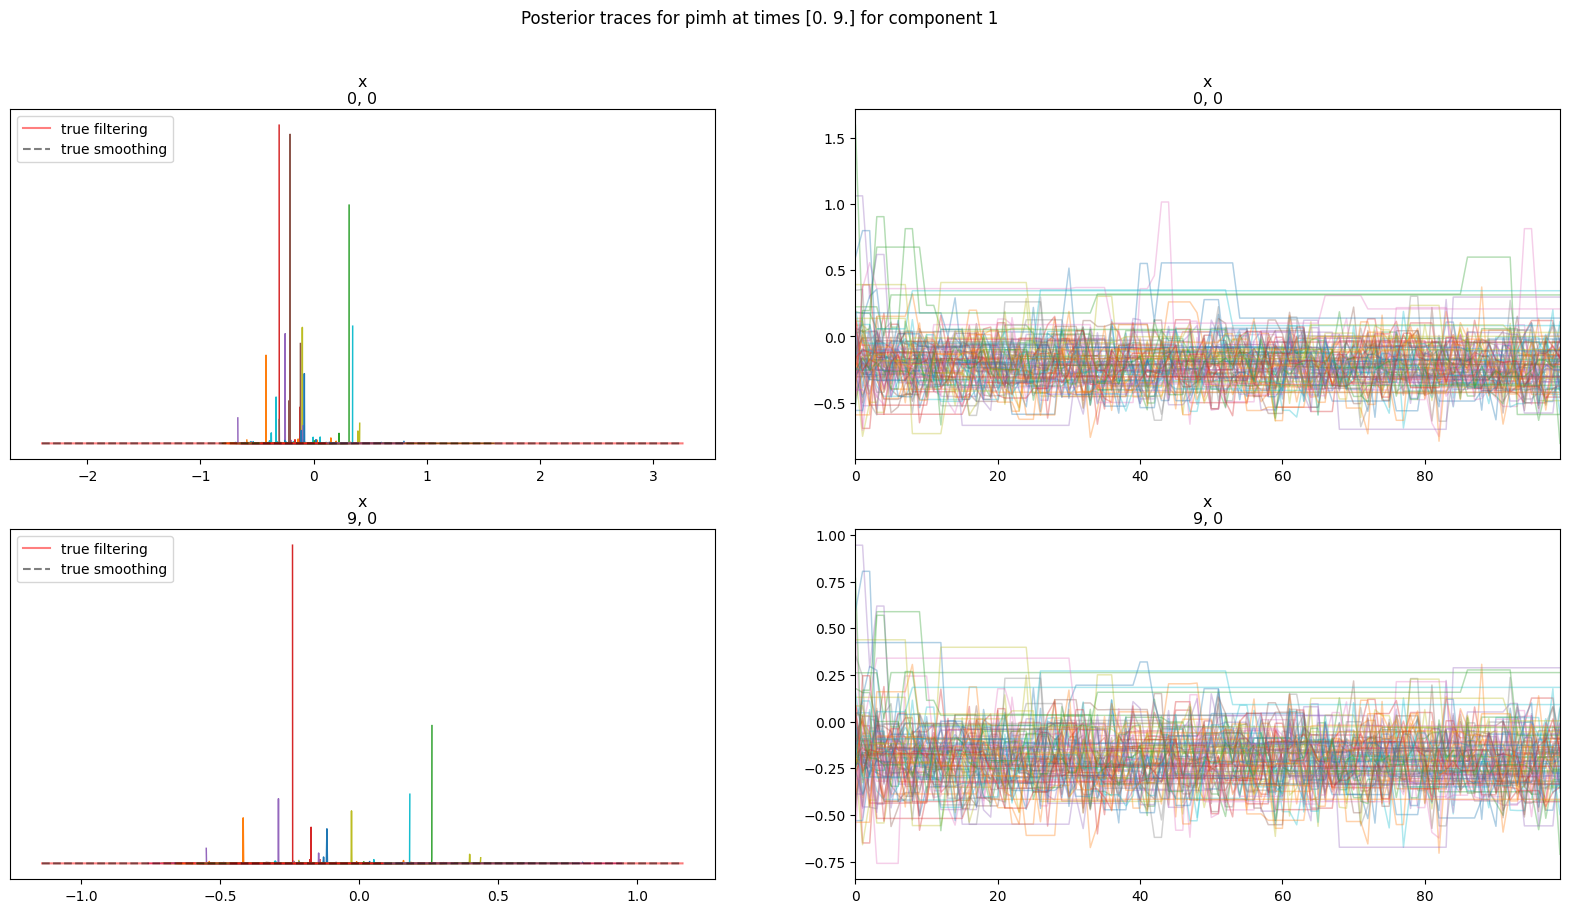

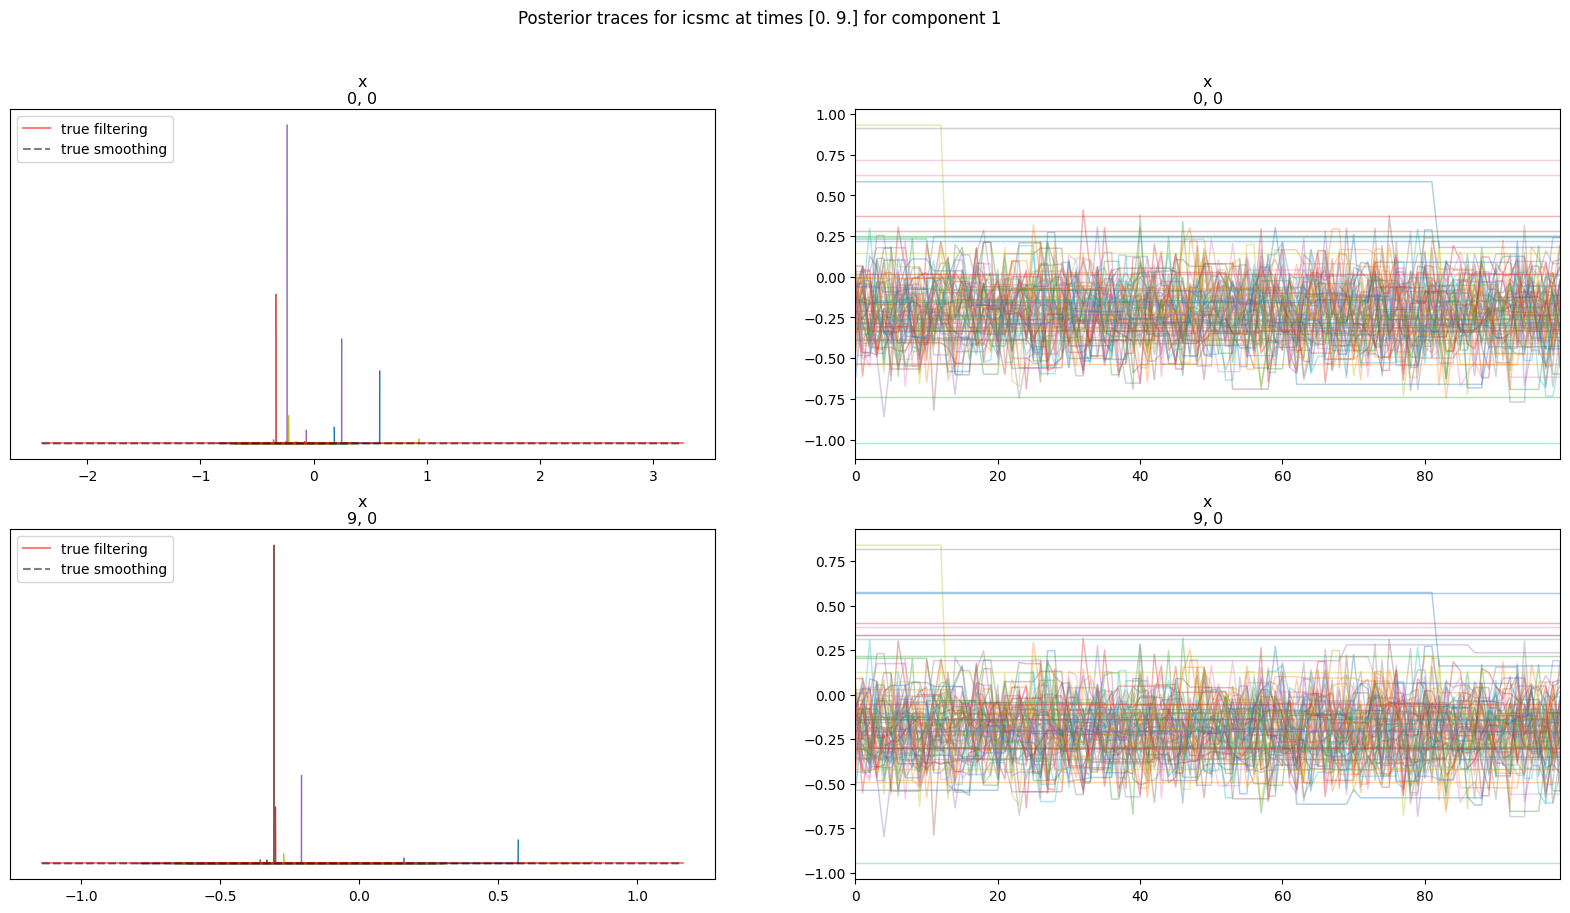

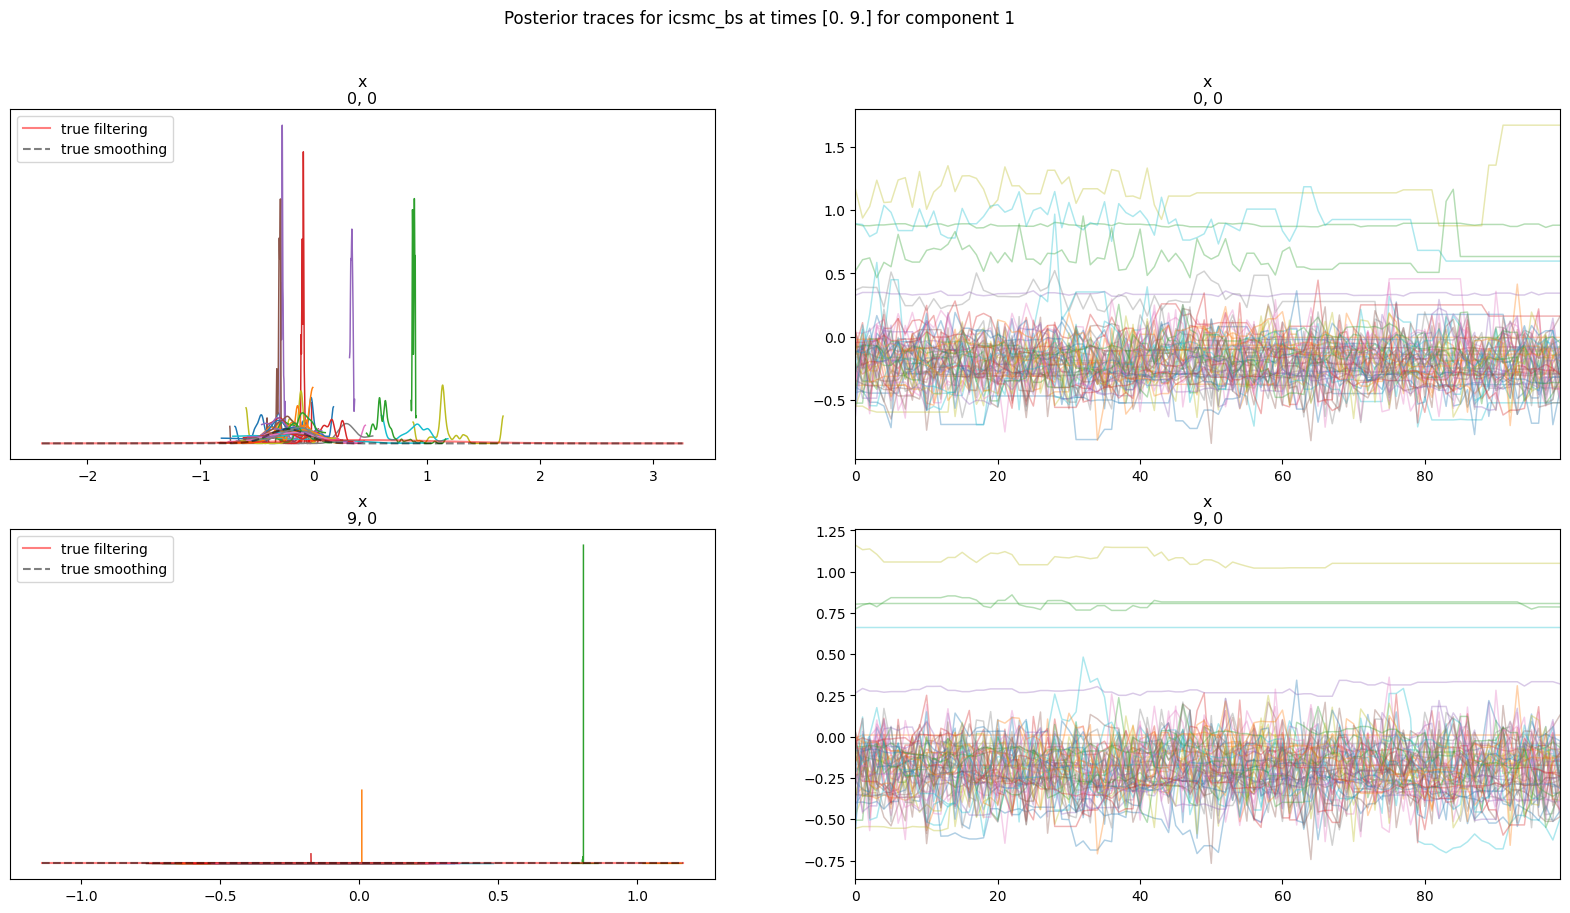

In [33]:
for alg_name in alg_names:
    idata = idatas[alg_name]
    for d in range(1, cdssm.dimX + 1):
        if np.any(true_vals_df[f'x_t_high_diff_{d}']):
            time_coords = cts_obs_times[true_vals_df[f'x_t_high_diff_{d}']]
            plot_coords = {'time': time_coords}
            if 'dimX' in posterior_coords:
                plot_coords['dimX'] = [d - 1]        
            plot_trace_kwargs = {'var_names': ['x'], 'compact': False, 'coords': plot_coords, 'figsize': (20, 5*len(time_coords))}
            axes = az.plot_trace(idata, **plot_trace_kwargs)
            plt.suptitle(f'Posterior traces for {alg_name} at times {plot_coords["time"]} for component {d}')

            dist_axes = axes[:, 0]
            trace_axes = axes[:, 1]

            for coord, ax in zip(cts_obs_times, dist_axes):
                t = int(coord)
                x_lim_lower = true_vals_df.loc[t, f'x_t_filt_mean_{d}{ext}'] - 4. * true_vals_df.loc[t, f'x_t_filt_std_{d}{ext}']
                x_lim_upper = true_vals_df.loc[t, f'x_t_filt_mean_{d}{ext}'] + 4. * true_vals_df.loc[t, f'x_t_filt_std_{d}{ext}']

                x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

                filt_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_filt_mean_{d}{ext}'], scale=true_vals_df.loc[t, f'x_t_filt_std_{d}{ext}'])
                smth_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_smth_mean_{d}{ext}'], scale=true_vals_df.loc[t, f'x_t_smth_std_{d}{ext}'])
                y_max = np.max([np.max(filt_pdf_linsp), np.max(smth_pdf_linsp)])

                ax.plot(x_linsp, filt_pdf_linsp, '-', c='red', alpha=0.5, label=r'true filtering')
                ax.plot(x_linsp, smth_pdf_linsp, '--', c='black', alpha=0.5, label=r'true smoothing')
                ax.legend(loc='upper left')


# Part 5 (Optional): Run a smoothing algorithm for a single Feynman-Kac model, review the results.

This part of the testing notebook may be used to run a smoothing method for a particular Feynman-Kac model within the notebook, as opposed to loading in results from the script.

## Diagnostic: Run a single particle filter for particle filter used in the experiment, and evaluate the genealogy 

In [ ]:
def obs_times_to_store(T, discrete_time=True):
    """
    Returns an array of 10 observation times and preprends time 1, giving a total of
    11 times. Uses the integer valued, discrete time index.
    """
    Ts_to_store_excl_1 = np.linspace(T // 10, T, num=10, dtype=np.int64)
    arr_1 = np.array([1], dtype=np.int64)
    obs_times_to_store = np.concatenate([arr_1] + [Ts_to_store_excl_1], axis=0)
    obs_times_to_store = obs_times_to_store - 1 # subtract 1 from all times
    if discrete_time:
        return obs_times_to_store
    else:
        if cdssm.isobservedat0:
            return np.array([cdssm.S(t) for t in obs_times_to_store], dtype=np.float64)
        else:
            return np.array([cdssm.S(t+1) for t in obs_times_to_store], dtype=np.float64)

In [ ]:
run_mcmc = False

if run_mcmc:
    # MCMC Params
    niter=100; Nx=100; num=10
    # methods = ['pimh', 'icsmc', 'icsmc_bs']

    # fk = sfk.BootstrapDA(cdssm=cdssm, data=y)
    # fk_bs = sfk.BootstrapReparameterisedDA(cdssm=cdssm, data=y)

    filt_fks = sfk.gen_all_fk_models(cdssm, y, smoothing=False)
    smth_fks = sfk.gen_all_fk_models(cdssm, y, smoothing=True)

    print(f'Running CDSSM MCMC algorithms for cdssm {cdssm_str} in parallel:')

    results_pimh = multiplexer(f=mcmc_worker, nruns=1, nprocs=0, seeding=True, fk=filt_fks, method=['pimh'], niter=niter, Nx=Nx, num=num)
    results_icsmc = multiplexer(f=mcmc_worker, nruns=1, nprocs=0, seeding=True, fk=filt_fks, method=['icsmc'], niter=niter, Nx=Nx, num=num)
    results_icsmc_bs = multiplexer(f=mcmc_worker, nruns=1, nprocs=0, seeding=True, fk=smth_fks, method=['icsmc_bs'], niter=niter, Nx=Nx, num=num)
    print('Algorithm runs complete.')

    idata_pimh = az.concat([r['output'] for r in results_pimh], dim='chain')
    idata_icsmc = az.concat([r['output'] for r in results_icsmc], dim='chain')
    idata_icsmc_bs = az.concat([r['output'] for r in results_icsmc_bs], dim='chain')
else:
    idata_pimh = az.from_netcdf(f'./results/pimh_1.nc')
    idata_icsmc = az.from_netcdf(f'./results/icsmc_1.nc')
    idata_icsmc = az.from_netcdf(f'./results/icsmc_bs_1.nc')

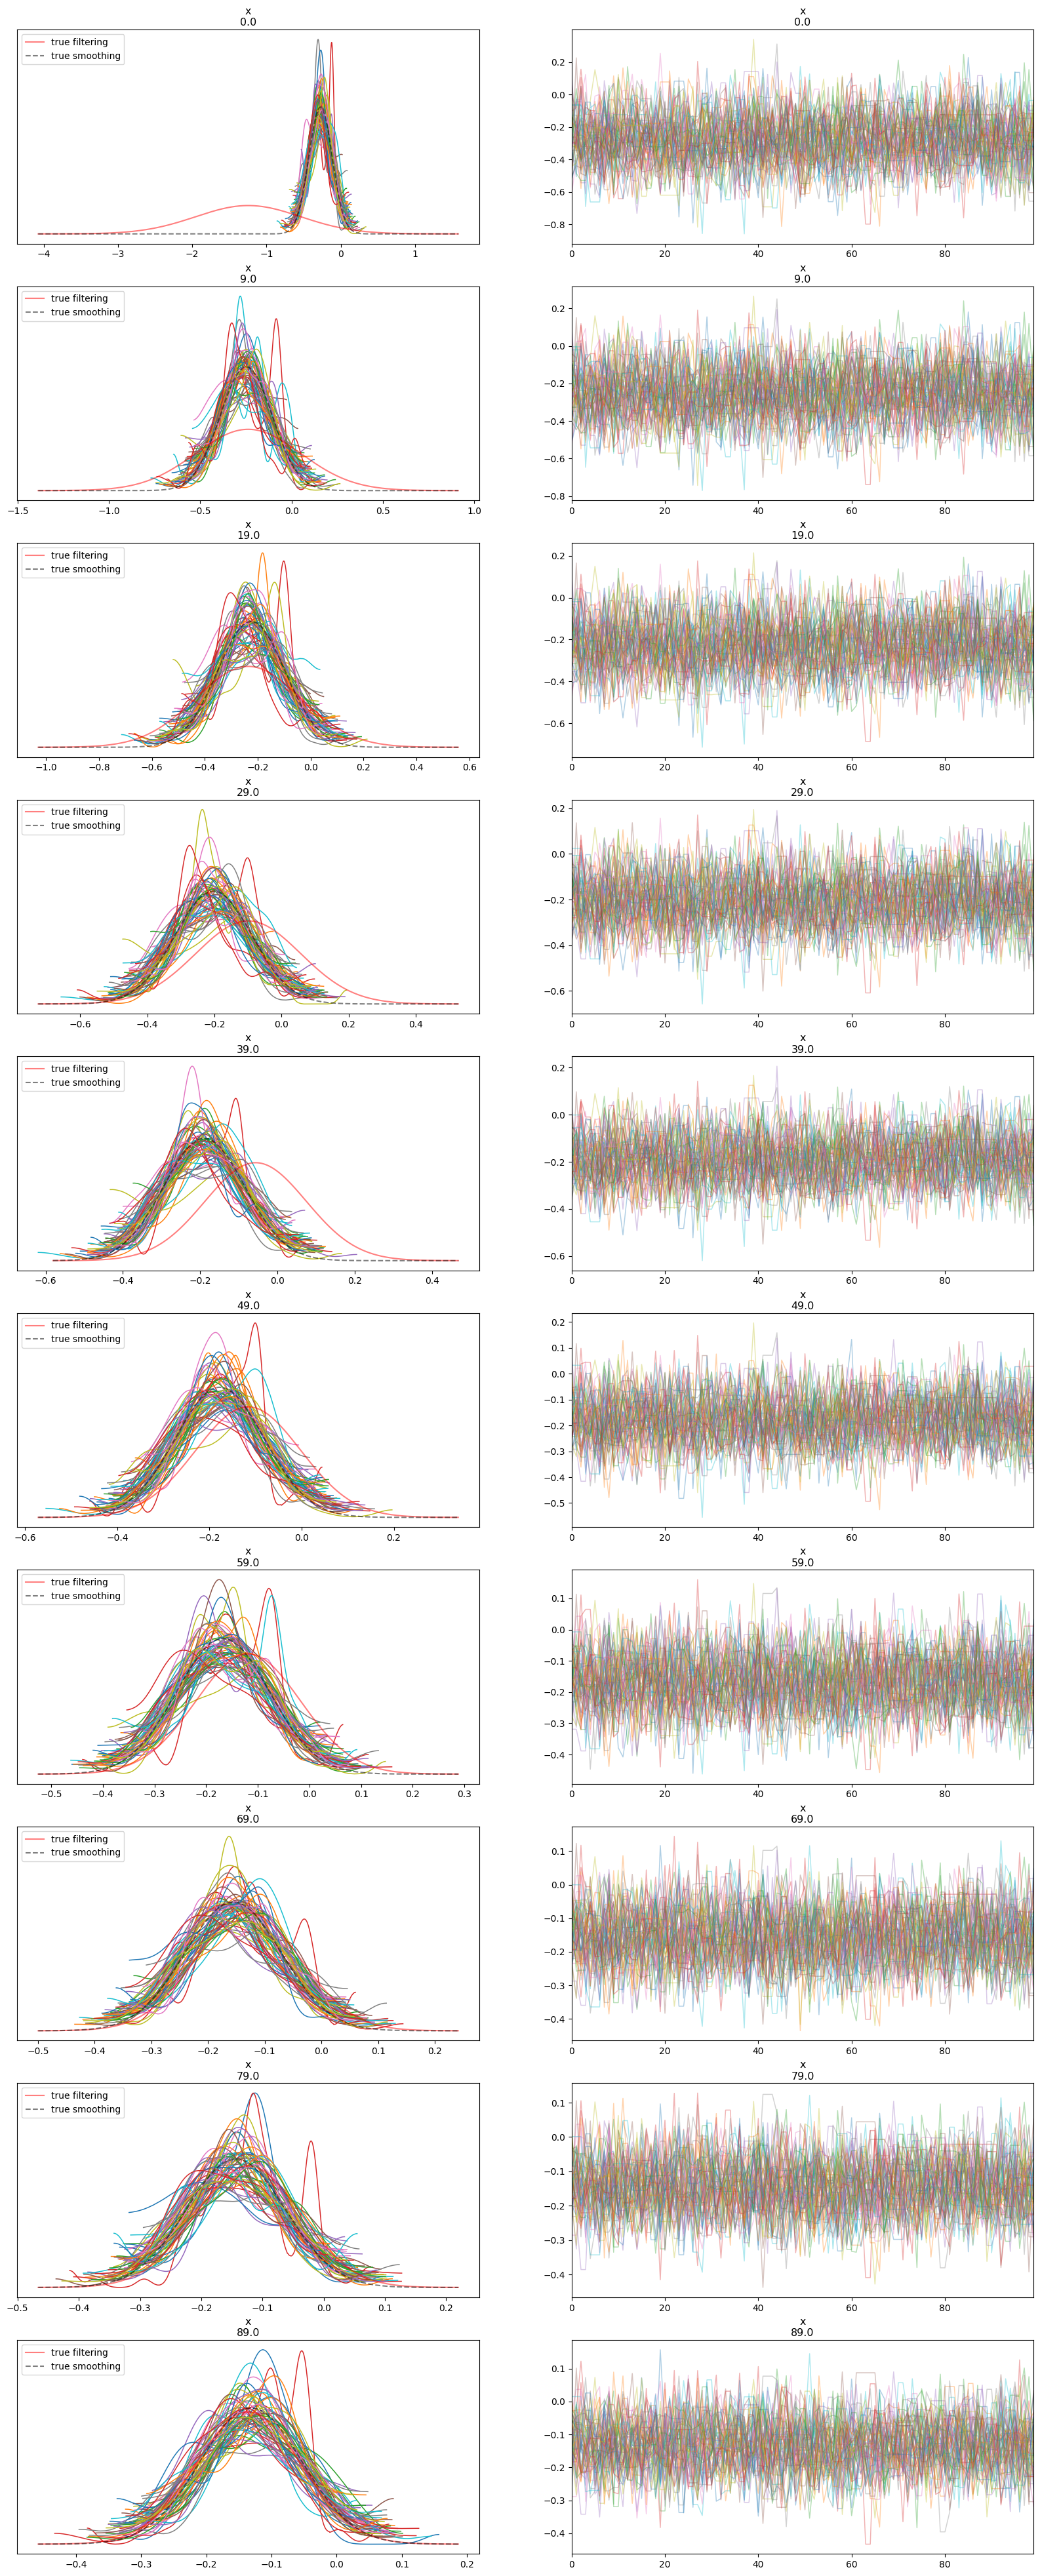

In [ ]:
# time_coords = np.arange(-1, 99, 10, dtype=np.float64)
# time_coords[0] = 0.0
# time_coords = time_coords.tolist()

time_coords = [0.0, 9.0, 19.0, 29.0, 39.0, 49.0, 59.0, 69.0, 79.0, 89.0]
# chain_coords = [0, 1, 2, 3, 4, 5, 6, 7]

axes = az.plot_trace(idata_pimh, var_names=['x'], coords={'time': time_coords}, compact=False, figsize=(20, 5*len(time_coords)))

dist_axes = axes[:, 0]
trace_axes = axes[:, 1]

for coord, ax in zip(time_coords, dist_axes):
    t = int(coord)
    x_lim_lower = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'] - 4. * true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']
    x_lim_upper = true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'] + 4. * true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}']

    x_linsp = np.linspace(x_lim_lower, x_lim_upper, num=1000)

    filt_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_filt_mean_{j}{ext}'], scale=true_vals_df.loc[t, f'x_t_filt_std_{j}{ext}'])
    smth_pdf_linsp = stats.norm.pdf(x_linsp, loc=true_vals_df.loc[t, f'x_t_smth_mean_{j}{ext}'], scale=true_vals_df.loc[t, f'x_t_smth_std_{j}{ext}'])
    y_max = np.max([np.max(filt_pdf_linsp), np.max(smth_pdf_linsp)])

    ax.plot(x_linsp, filt_pdf_linsp, '-', c='red', alpha=0.5, label=r'true filtering')
    ax.plot(x_linsp, smth_pdf_linsp, '--', c='black', alpha=0.5, label=r'true smoothing')
    ax.legend(loc='upper left')
